In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import ViTForImageClassification
import pickle
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [2]:
# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [3]:
# Define transformations
image_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

In [4]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
from torchvision import transforms

class ImageDataset(Dataset):
    def __init__(self, dataframe, images_folder, image_transforms):
        self.dataframe = dataframe
        self.images_folder = images_folder
        self.image_transforms = image_transforms

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        label = 1 if row['Label'] == 'fake' else 0
        image_id = row['Image id']

        image_path = os.path.join(self.images_folder, image_id)
        if not os.path.exists(image_path):
            raise FileNotFoundError(f"{image_path} not found")


        image = Image.open(image_path).convert('RGB')
        image = self.image_transforms(image)

        label = int(label)
        assert 0 <= label < 2, f"Label {label} out of range"

        return {
            'original_label': label,
            'pixel_values': image,
            'label': torch.tensor(label, dtype=torch.long)
        }

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer
from torchvision import transforms
from PIL import Image
import os

# Load the CSV file
csv_path = '/kaggle/input/datasets/moutusirahmanbristi/bhm-bangla-hate-meme/Dataset_text.csv'
df = pd.read_csv(csv_path)

# Verify column names
print(df.columns)

# Drop unnecessary columns if they exist
columns_to_drop = [col for col in ['Source', 'Domain', 'Unnamed: 5'] if col in df.columns]
df = df.drop(columns_to_drop, axis=1)

# Shuffle the dataframe
df = shuffle(df, random_state=42)

# Split the dataset
train_ratio = 0.6
val_ratio = 0.2
test_ratio = 0.2

train_data, val_test = train_test_split(df, train_size=train_ratio, random_state=42)
valid_data, test_data = train_test_split(val_test, train_size=val_ratio / (val_ratio + test_ratio), random_state=42)


Index(['Image id', 'Caption', 'Label'], dtype='object')


In [6]:
# Path to the images folder
images_folder = '/kaggle/input/datasets/moutusirahmanbristi/bhm-bangla-hate-meme/Without text/'

# Initialize datasets
train_dataset = ImageDataset(train_data, images_folder, image_transforms)
valid_dataset = ImageDataset(valid_data, images_folder, image_transforms)
test_dataset = ImageDataset(test_data, images_folder, image_transforms)


In [7]:
# Initialize data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Sample 1:
Original Label: Real


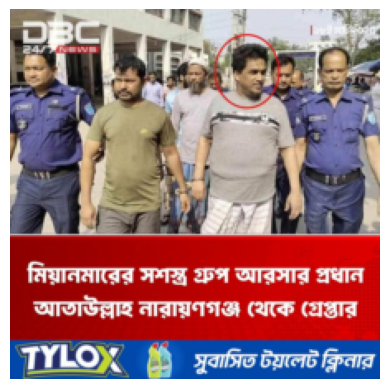


Sample 2:
Original Label: Fake


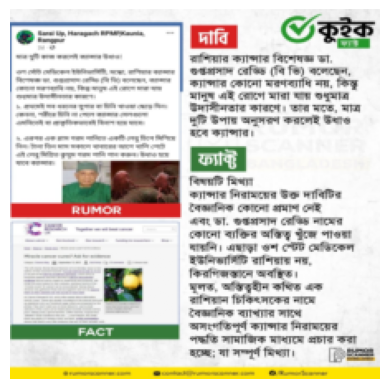


Sample 3:
Original Label: Real


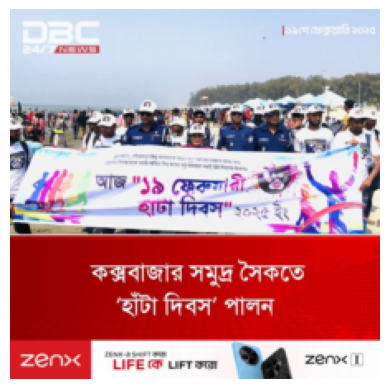


Sample 4:
Original Label: Real


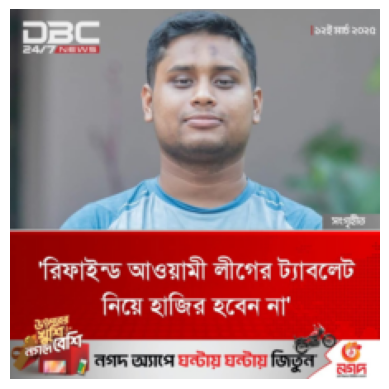


Sample 5:
Original Label: Real


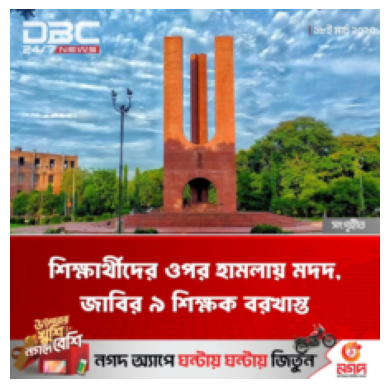

In [8]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
from torchvision import transforms
import matplotlib.pyplot as plt

class ImageDataset(Dataset):
    def __init__(self, dataframe, images_folder, image_transforms):
        self.dataframe = dataframe
        self.images_folder = images_folder
        self.image_transforms = image_transforms

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        label = 1 if row['Label'] == 'fake' else 0
        image_id = row['Image id']

        image_path = os.path.join(self.images_folder, image_id)
        if not os.path.exists(image_path):
            raise FileNotFoundError(f"{image_path} not found")


        image = Image.open(image_path).convert('RGB')
        image = self.image_transforms(image)

        label = int(label)
        assert 0 <= label < 2, f"Label {label} out of range"

        return {
            'original_label': label,
            'pixel_values': image,
            'label': torch.tensor(label, dtype=torch.long)
        }

def imshow(image, ax=None, title=None, normalize=False):
    # Imshow for Tensor.
    if ax is None:
        fig, ax = plt.subplots()
    image = image.numpy().transpose((1, 2, 0))
    if normalize:
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image = std * image + mean
        image = np.clip(image, 0, 1)
    ax.imshow(image)
    if title is not None:
        ax.set_title(title)
    ax.axis('off')
    return ax

def print_samples(dataloader, num_samples=5):
    count = 0
    for batch in dataloader:
        if count >= num_samples:
            break
        for i in range(len(batch['pixel_values'])):
            if count >= num_samples:
                break
            print(f"Sample {count+1}:")
            if batch['original_label'][i] == 1:
                print("Original Label: Fake")
            else:
                print("Original Label: Real")
            
            # Plot the image
            imshow(batch['pixel_values'][i])
            plt.show()
            print()
            count += 1

# Example DataFrame
data = {
    'Caption': ['বাংলা টেক্সট ১', 'বাংলা টেক্সট ২'],
    'Label': [0, 1],
    'Image id': ['image1', 'image2']
}
dataframe = df

# Path to the images folder
images_folder = '/kaggle/input/datasets/moutusirahmanbristi/bhm-bangla-hate-meme/Without text/'

# Initialize image transforms
image_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    #transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Initialize dataset
dataset = ImageDataset(dataframe, images_folder, image_transforms)

# Create DataLoader
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

# Print some samples from the dataset
print_samples(dataloader)


In [9]:
from transformers import ViTForImageClassification

model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=2,
    ignore_mismatched_sizes=True
)

model = model.to(device)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([2])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [10]:
optimizer = optim.AdamW(model.parameters(), lr=2e-4)
criterion = nn.CrossEntropyLoss()


In [11]:
if torch.cuda.is_available():
    model.cuda()

In [12]:
def train_one_epoch(model, data_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct_predictions = 0

    for batch in data_loader:
        optimizer.zero_grad()

        inputs = batch['pixel_values'].to(device)
        labels = batch['label'].to(device)

        outputs = model(inputs).logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct_predictions += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(data_loader.dataset)
    epoch_acc = correct_predictions.double() / len(data_loader.dataset)

    return epoch_loss, epoch_acc


def validate_one_epoch(model, data_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct_predictions = 0

    with torch.no_grad():
        for batch in data_loader:
            inputs = batch['pixel_values'].to(device)
            labels = batch['label'].to(device)

            outputs = model(inputs).logits
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct_predictions += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(data_loader.dataset)
    epoch_acc = correct_predictions.double() / len(data_loader.dataset)

    return epoch_loss, epoch_acc


In [13]:
num_epochs = 10
best_acc = 0.0

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    valid_loss, valid_acc = validate_one_epoch(model, valid_loader, criterion, device)

    print(f'Epoch {epoch+1}/{num_epochs}')
    print(f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f}')
    print(f'Valid Loss: {valid_loss:.4f} Acc: {valid_acc:.4f}')

    if valid_acc > best_acc:
        best_acc = valid_acc
        torch.save(model.state_dict(), 'best_model.pth')

print('Training complete')


Epoch 1/10
Train Loss: 0.0464 Acc: 0.9837
Valid Loss: 0.0428 Acc: 0.9911
Epoch 2/10
Train Loss: 0.0128 Acc: 0.9959
Valid Loss: 0.0257 Acc: 0.9956
Epoch 3/10
Train Loss: 0.0265 Acc: 0.9926
Valid Loss: 0.0543 Acc: 0.9878
Epoch 4/10
Train Loss: 0.0156 Acc: 0.9970
Valid Loss: 0.0358 Acc: 0.9956
Epoch 5/10
Train Loss: 0.0042 Acc: 0.9993
Valid Loss: 0.0254 Acc: 0.9956
Epoch 6/10
Train Loss: 0.0023 Acc: 0.9989
Valid Loss: 0.0346 Acc: 0.9933
Epoch 7/10
Train Loss: 0.0021 Acc: 0.9989
Valid Loss: 0.0373 Acc: 0.9956
Epoch 8/10
Train Loss: 0.0000 Acc: 1.0000
Valid Loss: 0.0388 Acc: 0.9956
Epoch 9/10
Train Loss: 0.0000 Acc: 1.0000
Valid Loss: 0.0395 Acc: 0.9956
Epoch 10/10
Train Loss: 0.0000 Acc: 1.0000
Valid Loss: 0.0401 Acc: 0.9956
Training complete


In [14]:
# Load the best model
model.load_state_dict(torch.load('best_model.pth'))

# Function to make predictions
def predict(model, data_loader, device):
    model.eval()
    predictions = []

    with torch.no_grad():
        for batch in data_loader:
            inputs = batch['pixel_values'].to(device)
            outputs = model(inputs).logits
            _, preds = torch.max(outputs, 1)
            predictions.extend(preds.cpu().numpy())

    return predictions

# Get predictions
test_predictions = predict(model, test_loader, device)


In [19]:
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

model.load_state_dict(torch.load('best_model.pth'))

def evaluate_model(model, test_loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            images = batch['pixel_values'].to(device)
            labels = batch['label'].to(device)

            outputs = model(images).logits
            _, preds = torch.max(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_labels = ['fake' if label == 1 else 'real' for label in all_labels]
    all_preds = ['fake' if pred == 1 else 'real' for pred in all_preds]

    
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')
    report = classification_report(all_labels, all_preds, target_names=['Real', 'Fake'])

    return accuracy, precision, recall, f1, report, all_labels, all_preds

# Example usage:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
accuracy, precision, recall, f1, report, all_labels, all_preds = evaluate_model(model, test_loader, device)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:")
print(report)


Accuracy: 0.9922
Precision: 0.9923
Recall: 0.9922
F1 Score: 0.9922

Classification Report:
              precision    recall  f1-score   support

        Real       0.98      1.00      0.99       436
        Fake       1.00      0.98      0.99       464

    accuracy                           0.99       900
   macro avg       0.99      0.99      0.99       900
weighted avg       0.99      0.99      0.99       900



In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(all_labels, all_preds):
    labels = ['fake', 'real']
    
    cm = confusion_matrix(all_labels, all_preds, labels=labels)

    plt.figure(figsize=(8,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels,
                yticklabels=labels)

    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.savefig('/kaggle/working/ViT_confusion_matrix.png')
    plt.show()
    

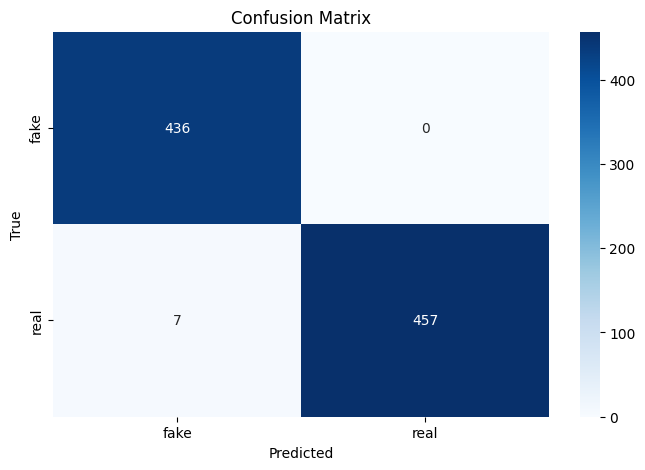

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
plot_confusion_matrix(all_labels, all_preds)